# **Flowers Recognition with Simple_CNN_vs_ResNet18_vs_VGG16 modles**

# ============================================
# IMPORT ALL NECESSARY LIBRARIES
# ============================================


In [ ]:
import pickle                          # For loading the label map file containing flower names
import numpy as np                      # For mathematical operations on arrays and matrices
import matplotlib.pyplot as plt          # For creating graphs and displaying images
import torch                            # Main PyTorch library for deep learning
import torch.nn as nn                    # For neural network layers and modules
import torch.optim as optim              # For optimization algorithms like Adam and SGD
import torch.nn.functional as F          # For functions like ReLU, softmax, and loss functions
import torchvision                       # For pre-trained models and computer vision utilities
import torchvision.transforms as transforms  # For image preprocessing and data augmentation
from torch.utils.data import DataLoader   # For loading data in batches during training
from torch.utils.data import random_split # For splitting dataset into training and validation sets
from torchvision.datasets import ImageFolder  # For automatically loading images from folders
import os                                # For file and folder operations (creating directories, checking paths)
from PIL import Image                     # For opening, manipulating, and saving images
from tqdm import tqdm                     # For creating progress bars to visualize training progress
import requests                          # For downloading files from the internet (dataset)
import tarfile                           # For extracting .tgz compressed files
import json                              # For saving results in JSON format
import warnings                          # For managing warning messages
warnings.filterwarnings('ignore')        # Ignore warning messages for cleaner output


# ============================================
# SETUP DEVICE AND FIX RANDOMNESS
# ============================================

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # Use GPU if available, otherwise CPU
print(f"Using device: {device}")                                        # Print which device we're using

torch.manual_seed(42)                                                   # Set random seed for PyTorch for reproducibility
np.random.seed(42)                                                      # Set random seed for NumPy for reproducibility


Using device: cuda


# ============================================
# LOAD AND UNDERSTAND THE LABEL MAP
# ============================================

In [ ]:
with open('label_map[1].pkl', 'rb') as f:                               # Open the pickle file in binary read mode
    label_map = pickle.load(f)                                          # Load the dictionary mapping flower names to numbers

print("Label map contents:", label_map)                                 # Display the mapping (e.g., {'daisy':0, 'dandelion':1, ...})

num_classes = len(label_map)                                            # Count number of flower classes (should be 5)
print(f"Number of classes: {num_classes}")                              # Print number of classes

idx_to_class = {v: k for k, v in label_map.items()}                    # Create reverse mapping (number to flower name)
print("Index to class mapping:", idx_to_class)                          # Display reverse mapping

class_names = [idx_to_class[i] for i in range(num_classes)]            # Create ordered list of class names
print("Class names in order:", class_names)                             # Print ordered class names

Label map contents: {'daisy': 0, 'dandelion': 1, 'sunflower': 2, 'tulip': 3, 'rose': 4}
Number of classes: 5
Index to class mapping: {0: 'daisy', 1: 'dandelion', 2: 'sunflower', 3: 'tulip', 4: 'rose'}
Class names in order: ['daisy', 'dandelion', 'sunflower', 'tulip', 'rose']


# ============================================
# DOWNLOAD AND PREPARE THE FLOWER DATASET
# ============================================

In [ ]:
data_dir = 'flower_data'                                                # Name of folder to store dataset
os.makedirs(data_dir, exist_ok=True)                                    # Create folder if it doesn't exist

dataset_path = os.path.join(data_dir, 'flower_photos')                  # Full path to extracted dataset

if not os.path.exists(dataset_path):                                    # Check if dataset already exists
    dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"  # URL for flower dataset
    print("Downloading flower dataset...")                              # Print download message

    response = requests.get(dataset_url, stream=True)                   # Send request to download with streaming
    total_size = int(response.headers.get('content-length', 0))        # Get total file size for progress bar

    with open('flower_photos.tgz', 'wb') as file:                       # Open file to save downloaded content
        with tqdm(total=total_size, unit='B', unit_scale=True, desc="Downloading") as pbar:  # Create progress bar
            for data in response.iter_content(chunk_size=1024):        # Download in 1KB chunks
                file.write(data)                                        # Write chunk to file
                pbar.update(len(data))                                  # Update progress bar

    print("Extracting dataset...")                                      # Print extraction message
    with tarfile.open('flower_photos.tgz', 'r:gz') as tar:              # Open the tar file
        tar.extractall(data_dir)                                        # Extract to data directory
    print("Dataset extracted successfully!")                            # Print success message
else:
    print("Dataset already exists, skipping download.")                 # Skip if dataset exists

Downloading: 100%|██████████| 229M/229M [00:03<00:00, 63.1MB/s]


Extracting dataset...
Dataset extracted successfully!


# ============================================
# DEFINE IMAGE TRANSFORMATIONS
# ============================================

In [ ]:
IMG_SIZE = 224                                                          # Standard size for ResNet and VGG

train_transform = transforms.Compose([                                  # Transformations for training data
    transforms.Resize((IMG_SIZE, IMG_SIZE)),                            # Resize all images to 224x224
    transforms.RandomHorizontalFlip(p=0.5),                             # Randomly flip images horizontally 50% of time
    transforms.RandomRotation(degrees=15),                              # Randomly rotate images up to 15 degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),  # Randomly adjust colors
    transforms.ToTensor(),                                              # Convert PIL image to PyTorch tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize with ImageNet stats
])

val_transform = transforms.Compose([                                    # Transformations for validation data
    transforms.Resize((IMG_SIZE, IMG_SIZE)),                            # Resize all images to 224x224
    transforms.ToTensor(),                                              # Convert PIL image to PyTorch tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize with ImageNet stats
])

print("Transformations defined successfully!")                          # Print success message

Transformations defined successfully!


# ============================================
# LOAD AND SPLIT THE DATASET
# ============================================


In [ ]:
full_dataset = ImageFolder(root=dataset_path)                           # Load dataset using ImageFolder

print(f"Classes found: {full_dataset.classes}")                         # Print all class names
print(f"Total images: {len(full_dataset)}")                             # Print total number of images

train_size = int(0.8 * len(full_dataset))                               # 80% for training
val_size = len(full_dataset) - train_size                               # 20% for validation
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])  # Split dataset

train_dataset.dataset.transform = train_transform                       # Apply training transforms to training data
val_dataset.dataset.transform = val_transform                           # Apply validation transforms to validation data

batch_size = 32                                                         # Number of images to process at once

train_loader = DataLoader(                                              # Create data loader for training
    train_dataset,                                                      # Training dataset
    batch_size=batch_size,                                              # Batch size
    shuffle=True,                                                       # Shuffle data to avoid learning order bias
    num_workers=2,                                                      # Use 2 CPU processes for faster loading
    pin_memory=True if device == 'cuda' else False                      # Faster GPU transfer if using CUDA
)

val_loader = DataLoader(                                                # Create data loader for validation
    val_dataset,                                                        # Validation dataset
    batch_size=batch_size,                                              # Batch size
    shuffle=False,                                                      # No need to shuffle validation data
    num_workers=2,                                                      # Use 2 CPU processes
    pin_memory=True if device == 'cuda' else False                      # Faster GPU transfer if using CUDA
)

print(f"Training samples: {len(train_dataset)}")                        # Print number of training samples
print(f"Validation samples: {len(val_dataset)}")                        # Print number of validation samples
print(f"Training batches per epoch: {len(train_loader)}")               # Print number of training batches
print(f"Validation batches per epoch: {len(val_loader)}")               # Print number of validation batches

Classes found: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Total images: 3670
Training samples: 2936
Validation samples: 734
Training batches per epoch: 92
Validation batches per epoch: 23


# ============================================
# MODEL 1 - SIMPLE CNN FROM SCRATCH
# ============================================


In [ ]:
class SimpleCNN(nn.Module):                                             # Define SimpleCNN class inheriting from nn.Module
    def __init__(self, num_classes=5):                                  # Constructor method
        super(SimpleCNN, self).__init__()                               # Call parent class constructor

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)        # First conv: 3 input channels (RGB), 32 output channels
        self.bn1 = nn.BatchNorm2d(32)                                   # Batch normalization for first conv layer
        self.pool1 = nn.MaxPool2d(2, 2)                                 # Max pooling: reduces size by half (224->112)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)       # Second conv: 32->64 channels
        self.bn2 = nn.BatchNorm2d(64)                                   # Batch normalization for second conv layer
        self.pool2 = nn.MaxPool2d(2, 2)                                 # Max pooling: 112->56

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)      # Third conv: 64->128 channels
        self.bn3 = nn.BatchNorm2d(128)                                  # Batch normalization for third conv layer
        self.pool3 = nn.MaxPool2d(2, 2)                                 # Max pooling: 56->28

        self.flattened_size = 128 * 28 * 28                             # Calculate flattened size: 128 * 28 * 28 = 100,352

        self.fc1 = nn.Linear(self.flattened_size, 512)                  # First fully connected layer: 100,352 -> 512
        self.dropout = nn.Dropout(0.5)                                  # Dropout 50% to prevent overfitting
        self.fc2 = nn.Linear(512, num_classes)                          # Output layer: 512 -> num_classes (5)

    def forward(self, x):                                                # Forward pass method
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))                 # Conv1 -> BatchNorm -> ReLU -> Pool1
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))                 # Conv2 -> BatchNorm -> ReLU -> Pool2
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))                 # Conv3 -> BatchNorm -> ReLU -> Pool3
        x = x.view(x.size(0), -1)                                       # Flatten the tensor (batch_size, 100352)
        x = F.relu(self.fc1(x))                                         # First fully connected layer with ReLU
        x = self.dropout(x)                                             # Apply dropout
        x = self.fc2(x)                                                 # Output layer (logits)
        return x                                                        # Return predictions

simple_cnn = SimpleCNN(num_classes=num_classes).to(device)              # Create SimpleCNN instance and move to device

total_params = sum(p.numel() for p in simple_cnn.parameters())          # Count total parameters
trainable_params = sum(p.numel() for p in simple_cnn.parameters() if p.requires_grad)  # Count trainable parameters
print(f"Simple CNN - Total parameters: {total_params:,}")               # Print total parameters
print(f"Simple CNN - Trainable parameters: {trainable_params:,}")       # Print trainable parameters

Simple CNN - Total parameters: 51,476,997
Simple CNN - Trainable parameters: 51,476,997


# ============================================
# MODEL 2 - RESNET18 (PRE-TRAINED)
# ============================================


In [ ]:
def create_resnet18(num_classes=5, fine_tune_all=False):                # Function to create ResNet18
    model = torchvision.models.resnet18(pretrained=True)                # Load pre-trained ResNet18

    if not fine_tune_all:                                               # If not fine-tuning all layers
        for param in model.parameters():                                # Loop through all parameters
            param.requires_grad = False                                 # Freeze them (don't update during training)

    num_features = model.fc.in_features                                 # Get number of features from last layer
    model.fc = nn.Linear(num_features, num_classes)                     # Replace final layer for our classes

    return model                                                        # Return modified model

resnet18 = create_resnet18(num_classes=num_classes, fine_tune_all=False).to(device)  # Create ResNet18 (only train final layer)

total_params = sum(p.numel() for p in resnet18.parameters())            # Count total parameters
trainable_params = sum(p.numel() for p in resnet18.parameters() if p.requires_grad)  # Count trainable parameters
print(f"ResNet18 - Total parameters: {total_params:,}")                 # Print total parameters
print(f"ResNet18 - Trainable parameters: {trainable_params:,}")         # Print trainable parameters

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 77.9MB/s]

ResNet18 - Total parameters: 11,179,077
ResNet18 - Trainable parameters: 2,565


# ============================================
# MODEL 3 - VGG16 (PRE-TRAINED)
# ============================================


In [ ]:
def create_vgg16(num_classes=5, fine_tune_all=False):                   # Function to create VGG16
    model = torchvision.models.vgg16(pretrained=True)                   # Load pre-trained VGG16

    if not fine_tune_all:                                               # If not fine-tuning all layers
        for param in model.features.parameters():                       # Loop through feature extraction layers
            param.requires_grad = False                                 # Freeze them

    num_features = model.classifier[6].in_features                      # Get features from last classifier layer
    model.classifier[6] = nn.Linear(num_features, num_classes)          # Replace final layer

    return model                                                        # Return modified model

vgg16 = create_vgg16(num_classes=num_classes, fine_tune_all=False).to(device)  # Create VGG16 (only train classifier)

total_params = sum(p.numel() for p in vgg16.parameters())               # Count total parameters
trainable_params = sum(p.numel() for p in vgg16.parameters() if p.requires_grad)  # Count trainable parameters
print(f"VGG16 - Total parameters: {total_params:,}")                    # Print total parameters
print(f"VGG16 - Trainable parameters: {trainable_params:,}")            # Print trainable parameters

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 147MB/s]


VGG16 - Total parameters: 134,281,029
VGG16 - Trainable parameters: 119,566,341


# ============================================
# TRAINING FUNCTION
# ============================================


In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10, model_name="Model"):
    model = model.to(device)                                            # Move model to device

    history = {                                                         # Dictionary to store training history
        'train_loss': [], 'train_acc': [],                              # Training metrics
        'val_loss': [], 'val_acc': []                                   # Validation metrics
    }

    best_val_acc = 0.0                                                  # Track best validation accuracy

    print(f"\n{'='*50}")                                                # Print separator
    print(f"TRAINING {model_name}")                                     # Print model name
    print(f"{'='*50}")                                                  # Print separator

    for epoch in range(num_epochs):                                     # Loop through epochs
        model.train()                                                   # Set model to training mode
        running_loss = 0.0                                              # Initialize running loss
        correct = 0                                                     # Initialize correct predictions
        total = 0                                                       # Initialize total samples

        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")  # Progress bar

        for images, labels in train_pbar:                               # Loop through batches
            images, labels = images.to(device), labels.to(device)       # Move data to device

            optimizer.zero_grad()                                       # Reset gradients
            outputs = model(images)                                     # Forward pass
            loss = criterion(outputs, labels)                           # Calculate loss
            loss.backward()                                             # Backward pass
            optimizer.step()                                            # Update weights

            running_loss += loss.item()                                 # Accumulate loss
            _, predicted = outputs.max(1)                               # Get predictions
            total += labels.size(0)                                     # Update total
            correct += predicted.eq(labels).sum().item()                # Update correct count

            train_pbar.set_postfix({'Loss': f"{loss.item():.4f}", 'Acc': f"{100.*correct/total:.2f}%"})

        train_loss = running_loss / len(train_loader)                   # Average training loss
        train_acc = 100. * correct / total                              # Training accuracy

        model.eval()                                                    # Set model to evaluation mode
        val_loss = 0.0                                                  # Initialize validation loss
        correct = 0                                                     # Initialize correct predictions
        total = 0                                                       # Initialize total samples

        with torch.no_grad():                                           # No gradient computation
            for images, labels in val_loader:                           # Loop through validation batches
                images, labels = images.to(device), labels.to(device)   # Move data to device
                outputs = model(images)                                 # Forward pass
                loss = criterion(outputs, labels)                       # Calculate loss

                val_loss += loss.item()                                 # Accumulate loss
                _, predicted = outputs.max(1)                           # Get predictions
                total += labels.size(0)                                 # Update total
                correct += predicted.eq(labels).sum().item()            # Update correct count

        val_loss = val_loss / len(val_loader)                           # Average validation loss
        val_acc = 100. * correct / total                                # Validation accuracy

        history['train_loss'].append(train_loss)                        # Save training loss
        history['train_acc'].append(train_acc)                          # Save training accuracy
        history['val_loss'].append(val_loss)                            # Save validation loss
        history['val_acc'].append(val_acc)                              # Save validation accuracy

        print(f"\nEpoch {epoch+1}/{num_epochs} Summary:")               # Print epoch summary
        print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")  # Training metrics
        print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")   # Validation metrics

        if val_acc > best_val_acc:                                      # If best validation accuracy
            best_val_acc = val_acc                                      # Update best accuracy
            torch.save(model.state_dict(), f'best_{model_name.lower().replace(" ", "_")}.pth')  # Save model
            print(f"  ✓ Saved best model with accuracy: {val_acc:.2f}%")  # Print save message

    print(f"\n{model_name} Training Complete!")                         # Training complete message
    print(f"Best Validation Accuracy: {best_val_acc:.2f}%")             # Print best accuracy

    return model, history                                               # Return trained model and history

# ============================================
# TRAIN ALL THREE MODELS
# ============================================


In [ ]:
num_epochs = 10                                                         # Number of epochs to train
criterion = nn.CrossEntropyLoss()                                       # Loss function for classification

results = {}                                                            # Dictionary to store all results

print("\n" + "-"*40)                                                    # Print separator
print("Training Simple CNN")                                            # Print model name
print("-"*40)                                                           # Print separator

optimizer_cnn = optim.Adam(simple_cnn.parameters(), lr=0.001)           # Adam optimizer for Simple CNN
simple_cnn, history_cnn = train_model(simple_cnn, train_loader, val_loader, criterion, optimizer_cnn, num_epochs, "Simple CNN")
results['Simple CNN'] = history_cnn                                     # Save results

print("\n" + "-"*40)                                                    # Print separator
print("Training ResNet18")                                              # Print model name
print("-"*40)                                                           # Print separator

optimizer_resnet = optim.Adam(resnet18.fc.parameters(), lr=0.001)       # Only optimize final layer
resnet18, history_resnet = train_model(resnet18, train_loader, val_loader, criterion, optimizer_resnet, num_epochs, "ResNet18")
results['ResNet18'] = history_resnet                                    # Save results

print("\n" + "-"*40)                                                    # Print separator
print("Training VGG16")                                                 # Print model name
print("-"*40)                                                           # Print separator

optimizer_vgg = optim.Adam(vgg16.classifier.parameters(), lr=0.001)     # Only optimize classifier layers
vgg16, history_vgg = train_model(vgg16, train_loader, val_loader, criterion, optimizer_vgg, num_epochs, "VGG16")
results['VGG16'] = history_vgg                                          # Save results


----------------------------------------
Training Simple CNN
----------------------------------------

TRAINING Simple CNN


Epoch 1/10 [Train]: 100%|██████████| 92/92 [00:13<00:00,  6.75it/s, Loss=1.3699, Acc=37.77%]



Epoch 1/10 Summary:
  Train Loss: 9.0004, Train Acc: 37.77%
  Val Loss: 1.2545, Val Acc: 46.87%
  ✓ Saved best model with accuracy: 46.87%


Epoch 2/10 [Train]: 100%|██████████| 92/92 [00:12<00:00,  7.23it/s, Loss=1.3049, Acc=43.53%]



Epoch 2/10 Summary:
  Train Loss: 1.3027, Train Acc: 43.53%
  Val Loss: 1.0755, Val Acc: 55.99%
  ✓ Saved best model with accuracy: 55.99%


...


Epoch 8/10 Summary:
  Train Loss: 0.5016, Train Acc: 96.76%
  Val Loss: 2.8815, Val Acc: 88.42%
  ✓ Saved best model with accuracy: 88.42%


Epoch 9/10 [Train]: 100%|██████████| 92/92 [00:21<00:00,  4.29it/s, Loss=2.5622, Acc=95.78%]



Epoch 9/10 Summary:
  Train Loss: 1.1519, Train Acc: 95.78%
  Val Loss: 6.9548, Val Acc: 85.69%


Epoch 10/10 [Train]: 100%|██████████| 92/92 [00:21<00:00,  4.30it/s, Loss=1.0903, Acc=96.83%]



Epoch 10/10 Summary:
  Train Loss: 0.8520, Train Acc: 96.83%
  Val Loss: 5.8063, Val Acc: 90.05%
  ✓ Saved best model with accuracy: 90.05%

VGG16 Training Complete!
Best Validation Accuracy: 90.05%


# ============================================
# COMPARE AND FIND BEST MODEL
# ============================================


In [ ]:
best_model_name = None                                                  # Initialize best model name
best_accuracy = 0                                                       # Initialize best accuracy
best_model_instance = None                                              # Initialize best model instance
best_history = None                                                     # Initialize best history

print("\n" + "-"*40)                                                    # Print separator
print("Model Performance Summary")                                      # Print header
print("-"*40)                                                           # Print separator
print(f"{'Model':<15} {'Final Acc':<12} {'Best Acc':<12}")              # Print table header
print("-"*40)                                                           # Print separator

for model_name in results.keys():                                       # Loop through all models
    final_acc = results[model_name]['val_acc'][-1]                      # Get final accuracy
    best_acc = max(results[model_name]['val_acc'])                      # Get best accuracy

    print(f"{model_name:<15} {final_acc:>6.2f}%      {best_acc:>6.2f}%")  # Print model performance

    if best_acc > best_accuracy:                                        # If this model is better
        best_accuracy = best_acc                                        # Update best accuracy
        best_model_name = model_name                                    # Update best model name

        if model_name == 'Simple CNN':                                  # If Simple CNN is best
            best_model_instance = simple_cnn                            # Save Simple CNN instance
            best_history = history_cnn                                  # Save its history
        elif model_name == 'ResNet18':                                  # If ResNet18 is best
            best_model_instance = resnet18                              # Save ResNet18 instance
            best_history = history_resnet                               # Save its history
        else:                                                           # If VGG16 is best
            best_model_instance = vgg16                                 # Save VGG16 instance
            best_history = history_vgg                                  # Save its history

print("\n" + "="*50)                                                    # Print separator
print(f"🏆 BEST MODEL: {best_model_name} with {best_accuracy:.2f}% accuracy")  # Print best model
print("="*50)


----------------------------------------
Model Performance Summary
----------------------------------------
Model           Final Acc    Best Acc    
----------------------------------------
Simple CNN       61.58%       62.40%
ResNet18         90.19%       90.19%
VGG16            90.05%       90.05%

🏆 BEST MODEL: ResNet18 with 90.19% accuracy


# ============================================
# VISUALIZE COMPARISON
# ============================================


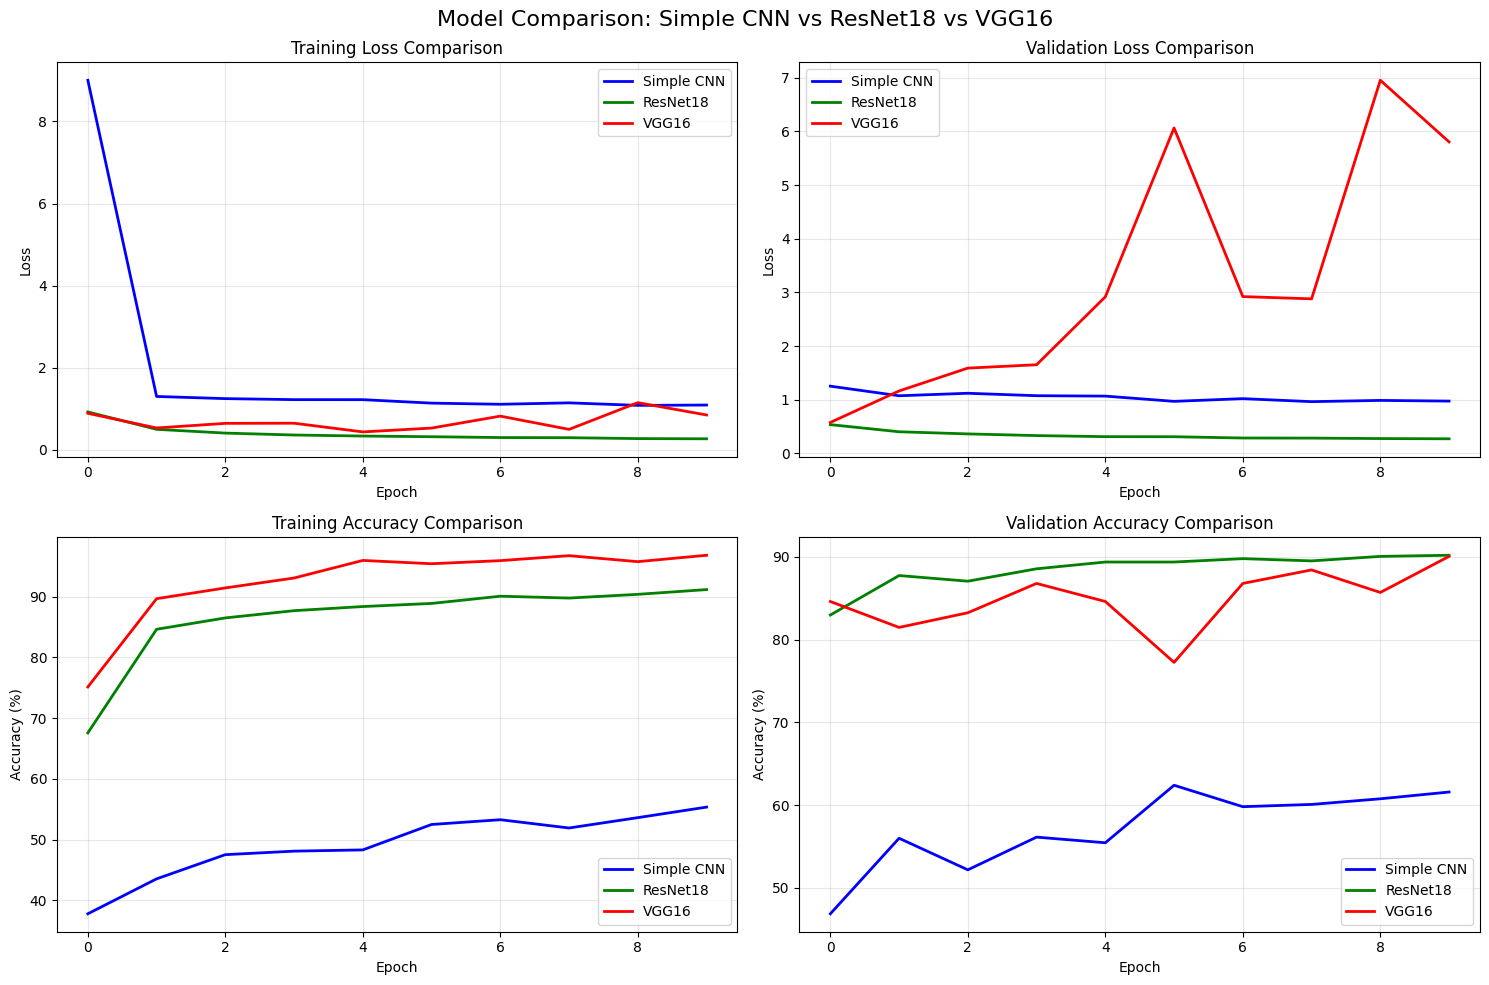

Comparison graph saved as 'model_comparison.png'


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))                        # Create 2x2 subplot figure
fig.suptitle('Model Comparison: Simple CNN vs ResNet18 vs VGG16', fontsize=16)  # Main title

colors = {'Simple CNN': 'blue', 'ResNet18': 'green', 'VGG16': 'red'}    # Colors for each model

ax = axes[0, 0]                                                         # Top-left subplot
for model_name, history in results.items():                             # Loop through models
    ax.plot(history['train_loss'], label=model_name, color=colors[model_name], linewidth=2)  # Plot training loss
ax.set_xlabel('Epoch')                                                  # X-axis label
ax.set_ylabel('Loss')                                                   # Y-axis label
ax.set_title('Training Loss Comparison')                                # Title
ax.legend()                                                             # Show legend
ax.grid(True, alpha=0.3)                                                # Add grid

ax = axes[0, 1]                                                         # Top-right subplot
for model_name, history in results.items():                             # Loop through models
    ax.plot(history['val_loss'], label=model_name, color=colors[model_name], linewidth=2)  # Plot validation loss
ax.set_xlabel('Epoch')                                                  # X-axis label
ax.set_ylabel('Loss')                                                   # Y-axis label
ax.set_title('Validation Loss Comparison')                              # Title
ax.legend()                                                             # Show legend
ax.grid(True, alpha=0.3)                                                # Add grid

ax = axes[1, 0]                                                         # Bottom-left subplot
for model_name, history in results.items():                             # Loop through models
    ax.plot(history['train_acc'], label=model_name, color=colors[model_name], linewidth=2)  # Plot training accuracy
ax.set_xlabel('Epoch')                                                  # X-axis label
ax.set_ylabel('Accuracy (%)')                                           # Y-axis label
ax.set_title('Training Accuracy Comparison')                            # Title
ax.legend()                                                             # Show legend
ax.grid(True, alpha=0.3)                                                # Add grid

ax = axes[1, 1]                                                         # Bottom-right subplot
for model_name, history in results.items():                             # Loop through models
    ax.plot(history['val_acc'], label=model_name, color=colors[model_name], linewidth=2)  # Plot validation accuracy
ax.set_xlabel('Epoch')                                                  # X-axis label
ax.set_ylabel('Accuracy (%)')                                           # Y-axis label
ax.set_title('Validation Accuracy Comparison')                          # Title
ax.legend()                                                             # Show legend
ax.grid(True, alpha=0.3)                                                # Add grid

plt.tight_layout()                                                      # Adjust layout
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')       # Save figure
plt.show()                                                              # Display figure
print("Comparison graph saved as 'model_comparison.png'")               # Print save message

# ============================================
# SAVE BEST MODEL COMPLETE
# ============================================


In [ ]:
torch.save({                                                            # Save complete model information
    'model_state_dict': best_model_instance.state_dict(),               # Model weights
    'model_name': best_model_name,                                      # Model name
    'class_names': class_names,                                         # Class names
    'num_classes': num_classes,                                         # Number of classes
    'label_map': label_map,                                             # Original label map
    'idx_to_class': idx_to_class,                                       # Reverse mapping
    'history': best_history,                                            # Training history
    'best_accuracy': best_accuracy,                                     # Best accuracy achieved
    'input_size': IMG_SIZE,                                             # Input image size
    'transform': str(val_transform)                                     # Transform used
}, 'best_flower_classifier_complete.pth')                               # Save to file

torch.save(best_model_instance.state_dict(), 'best_flower_classifier_weights.pth')  # Save just weights

with open('best_model_info.json', 'w') as f:                            # Save model info as JSON
    json.dump({                                                         # Dictionary to save
        'model_name': best_model_name,                                  # Model name
        'class_names': class_names,                                     # Class names
        'num_classes': num_classes,                                     # Number of classes
        'best_accuracy': best_accuracy,                                 # Best accuracy
        'input_size': IMG_SIZE                                          # Input size
    }, f, indent=4)                                                     # Save with indentation

print(f"✓ Best model ({best_model_name}) saved as:")                    # Print save message
print("  - 'best_flower_classifier_complete.pth' (complete model)")     # Complete model file
print("  - 'best_flower_classifier_weights.pth' (weights only)")        # Weights only file
print("  - 'best_model_info.json' (model information)")                 # Info file

✓ Best model (ResNet18) saved as:
  - 'best_flower_classifier_complete.pth' (complete model)
  - 'best_flower_classifier_weights.pth' (weights only)
  - 'best_model_info.json' (model information)


# ============================================
# EVALUATE BEST MODEL IN DETAIL
# ============================================



Overall Validation Accuracy: 90.19%

Per-Class Accuracy:
------------------------------
daisy          : 90.24%
dandelion      : 90.86%
sunflower      : 93.10%
tulip          : 93.24%
rose           : 84.88%


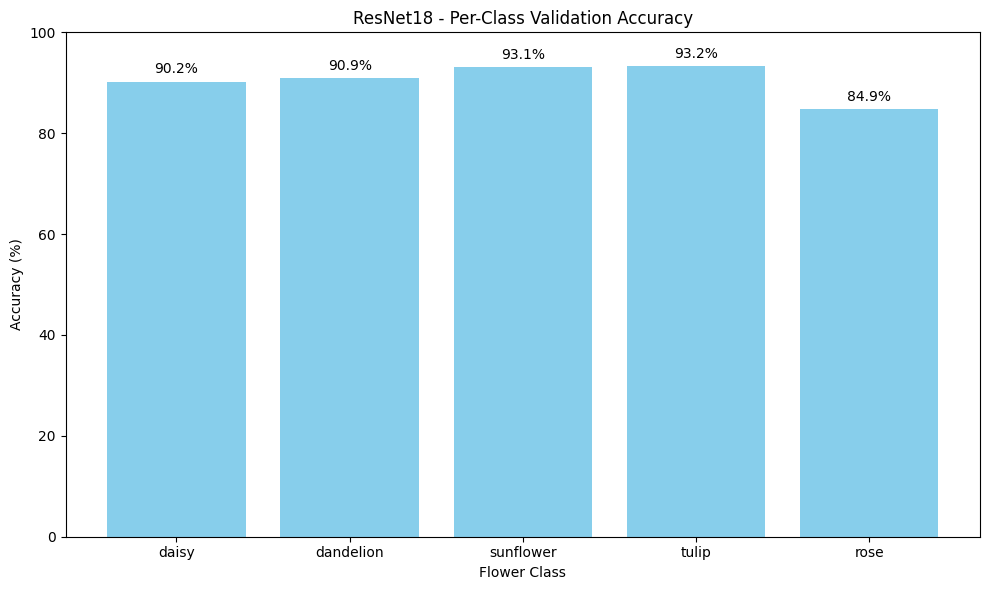

Per-class accuracy graph saved as 'best_model_per_class_accuracy.png'


In [ ]:
best_model_instance.eval()                                              # Set best model to evaluation mode

correct = 0                                                             # Initialize correct predictions
total = 0                                                               # Initialize total samples
class_correct = list(0. for i in range(num_classes))                   # Correct per class
class_total = list(0. for i in range(num_classes))                     # Total per class

with torch.no_grad():                                                   # No gradient computation
    for images, labels in val_loader:                                   # Loop through validation batches
        images, labels = images.to(device), labels.to(device)           # Move data to device
        outputs = best_model_instance(images)                           # Forward pass
        _, predicted = torch.max(outputs, 1)                            # Get predictions

        total += labels.size(0)                                         # Update total
        correct += (predicted == labels).sum().item()                   # Update correct count

        for i in range(len(labels)):                                    # For each sample in batch
            label = labels[i]                                           # Get true label
            class_correct[label] += (predicted[i] == label).item()     # Update class correct
            class_total[label] += 1                                     # Update class total

overall_acc = 100 * correct / total                                     # Calculate overall accuracy
print(f"\nOverall Validation Accuracy: {overall_acc:.2f}%")             # Print overall accuracy

print("\nPer-Class Accuracy:")                                          # Print per-class header
print("-" * 30)                                                         # Print separator
for i in range(num_classes):                                            # Loop through classes
    if class_total[i] > 0:                                              # If class has samples
        class_acc = 100 * class_correct[i] / class_total[i]             # Calculate class accuracy
        print(f"{class_names[i]:<15}: {class_acc:.2f}%")                # Print class accuracy

fig, ax = plt.subplots(figsize=(10, 6))                                 # Create figure for bar chart
accuracies = [100 * class_correct[i] / class_total[i] if class_total[i] > 0 else 0 for i in range(num_classes)]  # Class accuracies
bars = ax.bar(class_names, accuracies, color='skyblue')                 # Create bar chart
ax.set_xlabel('Flower Class')                                           # X-axis label
ax.set_ylabel('Accuracy (%)')                                           # Y-axis label
ax.set_title(f'{best_model_name} - Per-Class Validation Accuracy')     # Title
ax.set_ylim([0, 100])                                                   # Set y-axis limits

for bar, acc in zip(bars, accuracies):                                  # Add value labels on bars
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1, f'{acc:.1f}%', ha='center', va='bottom')

plt.tight_layout()                                                      # Adjust layout
plt.savefig('best_model_per_class_accuracy.png', dpi=300, bbox_inches='tight')  # Save figure
plt.show()                                                              # Display figure
print("Per-class accuracy graph saved as 'best_model_per_class_accuracy.png'")  # Print save message

# ============================================
# VISUALIZE BEST MODEL TRAINING
# ============================================

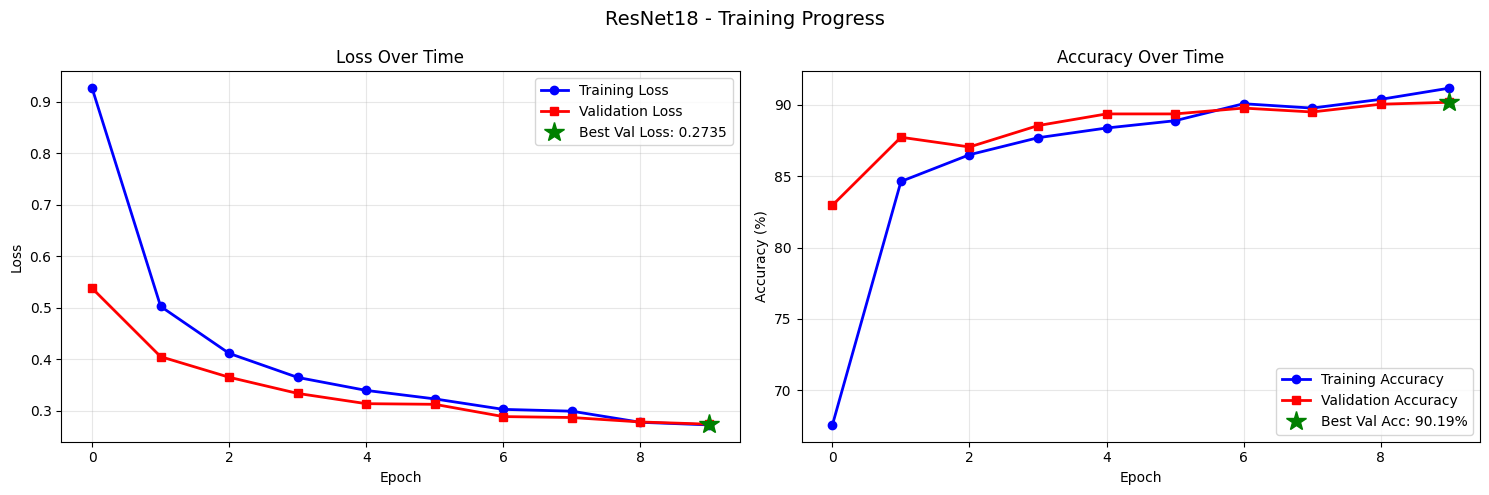

Best model training graph saved as 'best_model_training.png'


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))                         # Create 1x2 subplot figure
fig.suptitle(f'{best_model_name} - Training Progress', fontsize=14)     # Main title

ax = axes[0]                                                            # Left subplot
ax.plot(best_history['train_loss'], label='Training Loss', color='blue', linewidth=2, marker='o')  # Plot training loss
ax.plot(best_history['val_loss'], label='Validation Loss', color='red', linewidth=2, marker='s')  # Plot validation loss
ax.set_xlabel('Epoch')                                                  # X-axis label
ax.set_ylabel('Loss')                                                   # Y-axis label
ax.set_title('Loss Over Time')                                          # Title
ax.legend()                                                             # Show legend
ax.grid(True, alpha=0.3)                                                # Add grid

best_epoch = np.argmin(best_history['val_loss'])                        # Find epoch with best validation loss
best_loss = min(best_history['val_loss'])                               # Get best validation loss
ax.plot(best_epoch, best_loss, 'g*', markersize=15, label=f'Best Val Loss: {best_loss:.4f}')  # Mark best loss
ax.legend()                                                             # Update legend

ax = axes[1]                                                            # Right subplot
ax.plot(best_history['train_acc'], label='Training Accuracy', color='blue', linewidth=2, marker='o')  # Plot training accuracy
ax.plot(best_history['val_acc'], label='Validation Accuracy', color='red', linewidth=2, marker='s')  # Plot validation accuracy
ax.set_xlabel('Epoch')                                                  # X-axis label
ax.set_ylabel('Accuracy (%)')                                           # Y-axis label
ax.set_title('Accuracy Over Time')                                      # Title
ax.legend()                                                             # Show legend
ax.grid(True, alpha=0.3)                                                # Add grid

best_epoch = np.argmax(best_history['val_acc'])                         # Find epoch with best validation accuracy
best_acc_val = max(best_history['val_acc'])                             # Get best validation accuracy
ax.plot(best_epoch, best_acc_val, 'g*', markersize=15, label=f'Best Val Acc: {best_acc_val:.2f}%')  # Mark best accuracy
ax.legend()                                                             # Update legend

plt.tight_layout()                                                      # Adjust layout
plt.savefig('best_model_training.png', dpi=300, bbox_inches='tight')    # Save figure
plt.show()                                                              # Display figure
print("Best model training graph saved as 'best_model_training.png'")   # Print save message

# ============================================
# TEST ON SAMPLE IMAGES
# ============================================

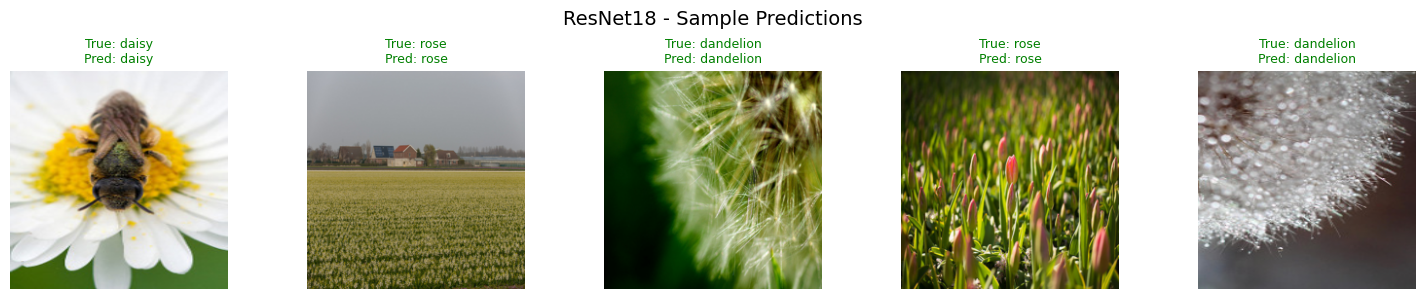

Sample predictions saved as 'best_model_predictions.png'


In [ ]:
def predict_and_display(model, images, labels, class_names, num_images=5):  # Function to predict and display
    model.eval()                                                        # Set model to evaluation mode
    images = images[:num_images]                                        # Take first num_images
    labels = labels[:num_images]                                        # Take corresponding labels

    fig, axes = plt.subplots(1, num_images, figsize=(15, 3))            # Create subplots
    fig.suptitle(f'{best_model_name} - Sample Predictions', fontsize=14)  # Main title

    with torch.no_grad():                                               # No gradient computation
        for i in range(num_images):                                     # Loop through images
            img = images[i].cpu()                                       # Move image to CPU
            true_label = class_names[labels[i].item()]                  # Get true label

            img_tensor = img.unsqueeze(0).to(device)                    # Add batch dimension and move to device
            outputs = model(img_tensor)                                 # Forward pass
            _, predicted = torch.max(outputs, 1)                        # Get prediction
            pred_label = class_names[predicted.item()]                  # Get predicted class name

            img_display = img.numpy().transpose((1, 2, 0))              # Convert tensor to image
            mean = np.array([0.485, 0.456, 0.406])                      # Mean for denormalization
            std = np.array([0.229, 0.224, 0.225])                       # Std for denormalization
            img_display = std * img_display + mean                      # Denormalize
            img_display = np.clip(img_display, 0, 1)                    # Clip values to valid range

            axes[i].imshow(img_display)                                 # Display image
            axes[i].axis('off')                                         # Hide axes
            color = 'green' if pred_label == true_label else 'red'      # Green if correct, red if wrong
            axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=9)  # Set title

    plt.tight_layout()                                                  # Adjust layout
    plt.savefig('best_model_predictions.png', dpi=300, bbox_inches='tight')  # Save figure
    plt.show()                                                          # Display figure

dataiter = iter(val_loader)                                             # Get iterator for validation loader
sample_images, sample_labels = next(dataiter)                           # Get one batch

predict_and_display(best_model_instance, sample_images, sample_labels, class_names)  # Display predictions
print("Sample predictions saved as 'best_model_predictions.png'")       # Print save message

# ============================================
# INFERENCE FUNCTION FOR NEW IMAGES
# ============================================

In [ ]:
def load_best_model(model_path='best_flower_classifier_complete.pth', device='cuda'):  # Function to load best model
    checkpoint = torch.load(model_path, map_location=device)            # Load checkpoint

    if checkpoint['model_name'] == 'Simple CNN':                        # If best model is Simple CNN
        model = SimpleCNN(num_classes=checkpoint['num_classes'])        # Create Simple CNN instance
    elif checkpoint['model_name'] == 'ResNet18':                        # If best model is ResNet18
        model = torchvision.models.resnet18(pretrained=False)           # Create ResNet18 instance
        num_features = model.fc.in_features                             # Get features
        model.fc = nn.Linear(num_features, checkpoint['num_classes'])   # Replace final layer
    else:                                                               # If best model is VGG16
        model = torchvision.models.vgg16(pretrained=False)              # Create VGG16 instance
        num_features = model.classifier[6].in_features                  # Get features
        model.classifier[6] = nn.Linear(num_features, checkpoint['num_classes'])  # Replace final layer

    model.load_state_dict(checkpoint['model_state_dict'])               # Load weights
    model = model.to(device)                                            # Move to device
    model.eval()                                                        # Set to evaluation mode

    return model, checkpoint['class_names']                             # Return model and class names

def classify_flower(image_path, model=None, class_names=None, model_path='best_flower_classifier_complete.pth'):  # Main inference function
    transform = transforms.Compose([                                    # Define transformations
        transforms.Resize((224, 224)),                                  # Resize to 224x224
        transforms.ToTensor(),                                          # Convert to tensor
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize
    ])

    if model is None or class_names is None:                            # If model not provided
        model, class_names = load_best_model(model_path)                # Load best model

    try:                                                                # Try to process image
        image = Image.open(image_path).convert('RGB')                    # Open and convert image
        image_tensor = transform(image).unsqueeze(0).to(device)         # Apply transforms and add batch dimension

        with torch.no_grad():                                           # No gradient computation
            outputs = model(image_tensor)                               # Forward pass
            probabilities = F.softmax(outputs, dim=1)                   # Convert to probabilities
            confidence, predicted = torch.max(probabilities, 1)         # Get highest probability

        predicted_class = class_names[predicted.item()]                 # Get predicted class name
        confidence_score = confidence.item()                            # Get confidence score

        plt.figure(figsize=(8, 6))                                      # Create figure
        plt.imshow(image)                                               # Display image
        plt.axis('off')                                                 # Hide axes
        plt.title(f"Predicted: {predicted_class}\nConfidence: {confidence_score:.2%}", fontsize=14, color='green')  # Set title
        plt.show()                                                      # Display figure

        return predicted_class, confidence_score                        # Return prediction

    except Exception as e:                                              # If error occurs
        print(f"Error processing image: {e}")                           # Print error
        return None, None                                               # Return None

print("\n" + "="*60)                                                    # Print separator
print("✅ MODEL COMPARISON COMPLETED SUCCESSFULLY!")                     # Print completion message
print("="*60)                                                           # Print separator
print(f"\n🏆 BEST MODEL: {best_model_name} with {best_accuracy:.2f}% accuracy")  # Print best model
print("\nFiles saved:")                                                 # Print files saved
print("  📊 model_comparison.png - Comparison graphs")                   # Comparison graphs
print(f"  📊 best_model_training.png - {best_model_name} training progress")  # Best model training
print(f"  📊 best_model_per_class_accuracy.png - Per-class accuracy")    # Per-class accuracy
print(f"  📊 best_model_predictions.png - Sample predictions")           # Sample predictions
print("  💾 best_flower_classifier_complete.pth - Complete best model")  # Complete model
print("  💾 best_flower_classifier_weights.pth - Best model weights")    # Weights only
print("  💾 best_model_info.json - Model information")                   # Model info
print("\nTo classify a new flower image:")                              # Usage instructions
print("  >>> predicted_class, confidence = classify_flower('path/to/your/flower.jpg')")  # Example usage
print("\n" + "="*60)                                                    # Print separator


✅ MODEL COMPARISON COMPLETED SUCCESSFULLY!

🏆 BEST MODEL: ResNet18 with 90.19% accuracy

Files saved:
  📊 model_comparison.png - Comparison graphs
  📊 best_model_training.png - ResNet18 training progress
  📊 best_model_per_class_accuracy.png - Per-class accuracy
  📊 best_model_predictions.png - Sample predictions
  💾 best_flower_classifier_complete.pth - Complete best model
  💾 best_flower_classifier_weights.pth - Best model weights
  💾 best_model_info.json - Model information

To classify a new flower image:
  >>> predicted_class, confidence = classify_flower('path/to/your/flower.jpg')

